<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/random_forest_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 Random Forest — Bank Marketing (UCI ML Repository)

**Módulo 3 · Árboles de Clasificación, Bagging y Boosting**  
Máster de FP en Business Analytics e Inteligencia Artificial

---

## Contexto del negocio

Un banco portugués lanzó una campaña de **marketing directo** por teléfono para convencer a sus clientes de suscribir un **depósito a plazo**. El dataset recoge las características de cada cliente (edad, trabajo, estado civil, saldo…) y el resultado de cada llamada.

**Objetivo:** construir un modelo que prediga si un cliente **va a suscribir el depósito** (`y = yes/no`) antes de llamarle, para que el banco pueda priorizar a los clientes con mayor probabilidad de conversión y optimizar el coste de la campaña.

**Dataset:** Bank Marketing · UCI ML Repository  
https://archive.ics.uci.edu/dataset/222/bank+marketing  
📊 45.211 clientes · 16 variables · Clasificación binaria

---

## Estructura del notebook

| # | Sección | Concepto clave |
|---|---------|----------------|
| 0 | Imports | — |
| 1 | Carga y EDA | Conocer el dataset antes de modelar |
| 2 | Preprocesamiento | Encoding, split, desbalance de clases |
| 3 | **RF Baseline** | Punto de partida con parámetros por defecto |
| 4 | **GridSearchCV** | Búsqueda exhaustiva en rejilla |
| 5 | **RandomizedSearchCV** | Búsqueda aleatoria en espacio amplio |
| 6 | **K-Fold Cross-Validation** | Validación robusta del mejor modelo |
| 7 | Comparativa final | Tabla de resultados y conclusiones |

---
## 0. Imports y configuración global

In [33]:
# ── Librerías generales ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# ── Scikit-learn: modelo ───────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: búsqueda de hiperparámetros ──────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

# ── Scikit-learn: métricas ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# ── Scikit-learn: preprocesamiento ─────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

# ── Scipy: distribuciones para RandomizedSearch ────────────────────────────
from scipy.stats import randint

# ── Reproducibilidad ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Estilo visual ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
COLOR_POS = '#2ecc71'   # verde  → suscribe
COLOR_NEG = '#e74c3c'   # rojo   → no suscribe
SEP = '-' * 52          # separador reutilizable en prints

print('Imports completados OK')

Imports completados OK


---
## 1. Carga de datos y EDA

In [34]:
# ── Cargamos el dataset desde UCI ─────────────────────────────────────────
# bank-full.csv: 45.211 filas, separador ';'
#
# Si tienes el fichero descargado localmente puedes usar:
#   df = pd.read_csv('bank-full.csv', sep=';')

import urllib.request
import zipfile
import io
import ssl

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'

# Contexto SSL sin verificación (necesario en algunos entornos de clase/empresa)
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

print('Descargando dataset desde UCI...')
with urllib.request.urlopen(url, context=ctx) as response:
    zf = zipfile.ZipFile(io.BytesIO(response.read()))
    with zf.open('bank-full.csv') as f:
        df = pd.read_csv(f, sep=';')

print('Dataset cargado OK')
print('Shape:', df.shape[0], 'filas x', df.shape[1], 'columnas')
df.head()

Descargando dataset desde UCI...
Dataset cargado OK
Shape: 45211 filas x 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [35]:
# ── Vista general del dataset ──────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [36]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [37]:
# ── Comprobación de valores nulos ─────────────────────────────────────────
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos')

Valores nulos por columna:
Sin valores nulos


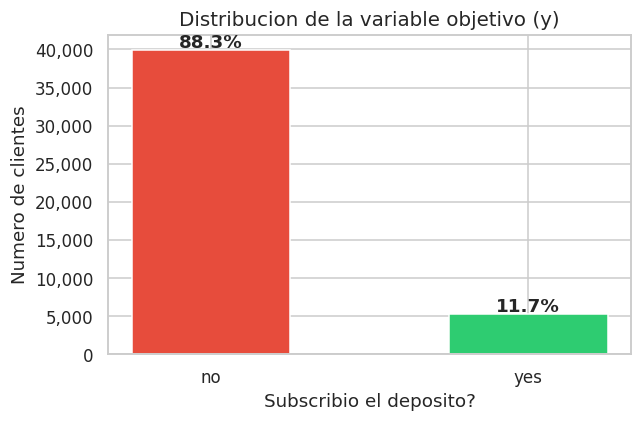

Desbalance: 88.3 % NO  vs  11.7 % YES
  -> Usaremos class_weight='balanced'


In [38]:
# ── Variable objetivo: desbalance de clases ───────────────────────────────
# IMPORTANTE: el desbalance afecta al entrenamiento.
# Si hay muchos más 'no' que 'yes', el modelo tiende a predecir siempre 'no'
# y consigue alta accuracy aunque no sea útil.

conteo = df['y'].value_counts()
pct    = df['y'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    conteo.index, conteo.values,
    color=[COLOR_NEG, COLOR_POS], edgecolor='white', width=0.5
)
for bar, p in zip(bars, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{p:.1f}%', ha='center', fontweight='bold', fontsize=12
    )
ax.set_title('Distribucion de la variable objetivo (y)', fontsize=13)
ax.set_xlabel('Subscribio el deposito?')
ax.set_ylabel('Numero de clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Desbalance:', pct['no'].round(1), '% NO  vs ', pct['yes'].round(1), '% YES')
print("  -> Usaremos class_weight='balanced'")

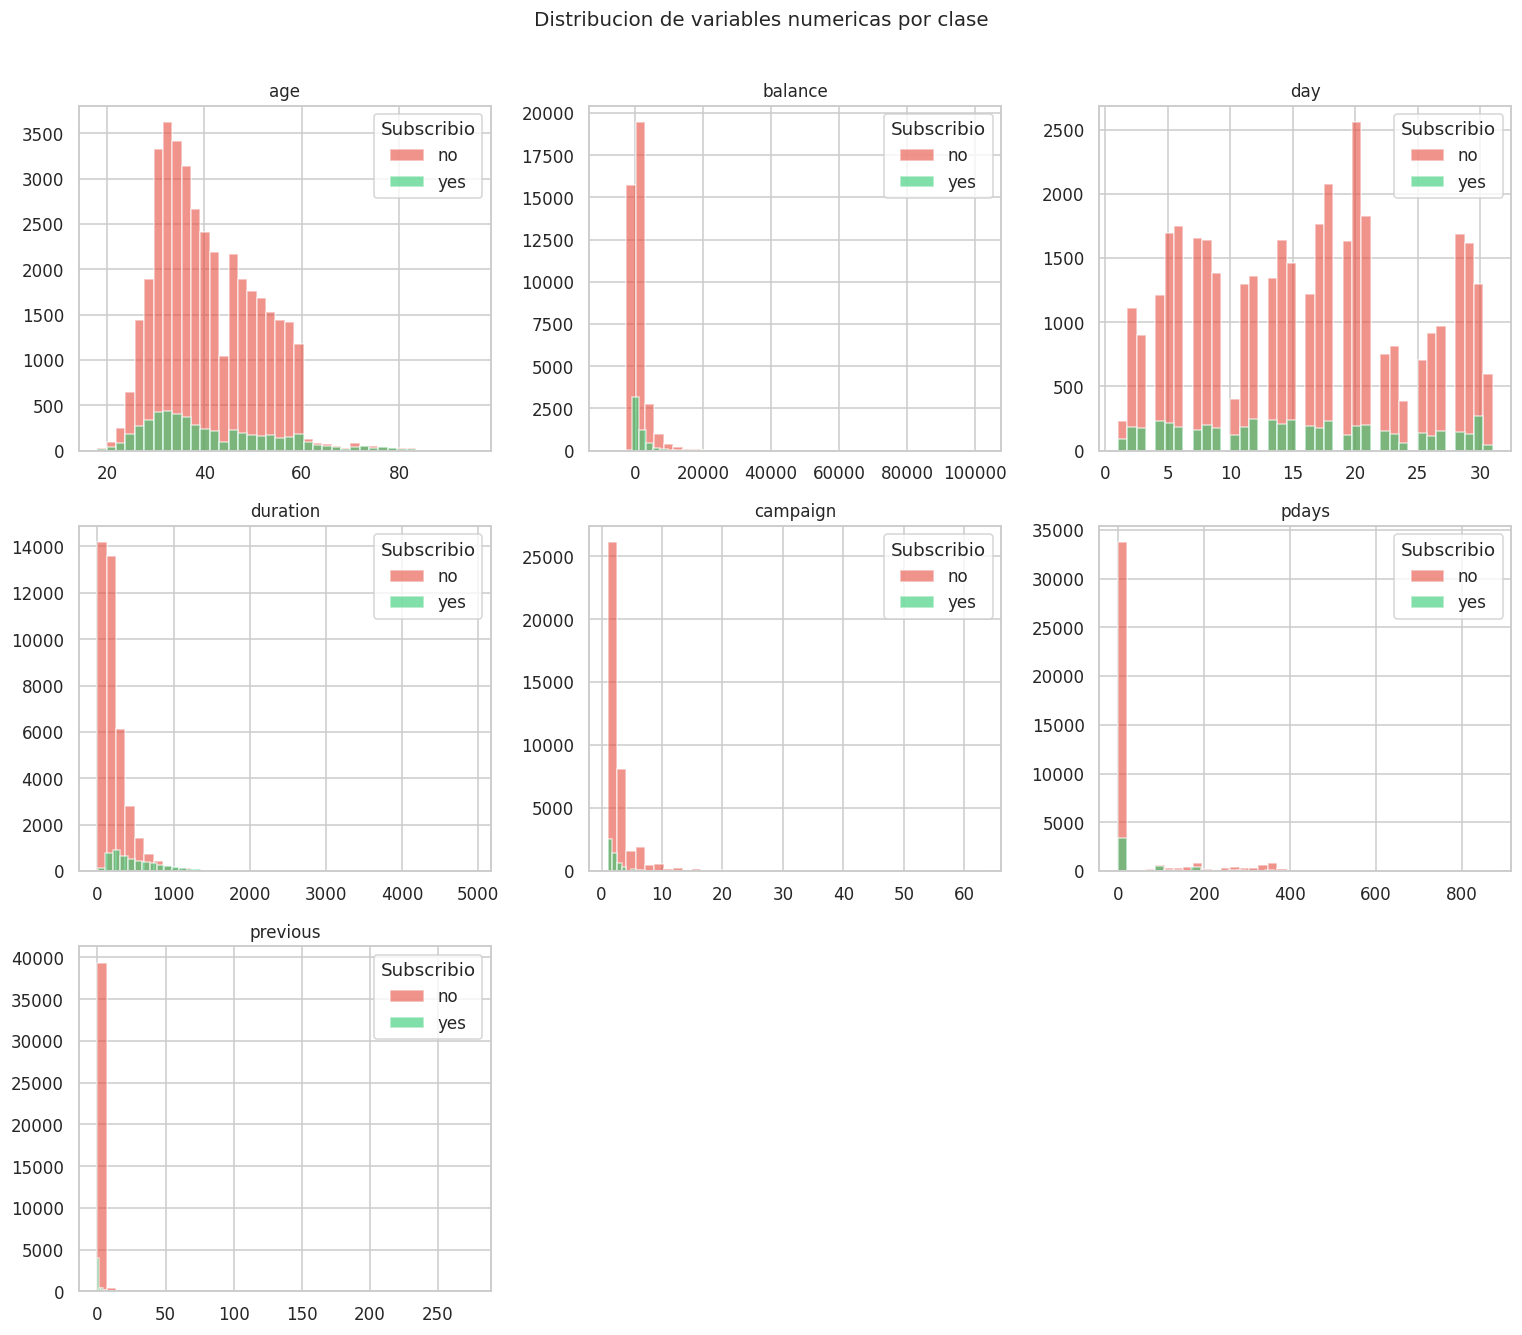

In [39]:
# ── Distribuciones de variables numéricas ─────────────────────────────────
# Superponemos histogramas por clase para ver qué variables
# separan mejor a los clientes que suscriben de los que no.

num_cols    = df.select_dtypes(include='number').columns.tolist()
n_num       = len(num_cols)
n_cols_plot = 3
n_rows_plot = int(np.ceil(n_num / n_cols_plot))  # calculado dinámicamente

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(14, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('no', COLOR_NEG), ('yes', COLOR_POS)]:
        axes[i].hist(
            df.loc[df['y'] == label, col],
            bins=40, alpha=0.6, color=color, label=label
        )
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(title='Subscribio')

# Ocultamos subplots sobrantes si el total no es múltiplo de n_cols_plot
for j in range(n_num, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribucion de variables numericas por clase', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

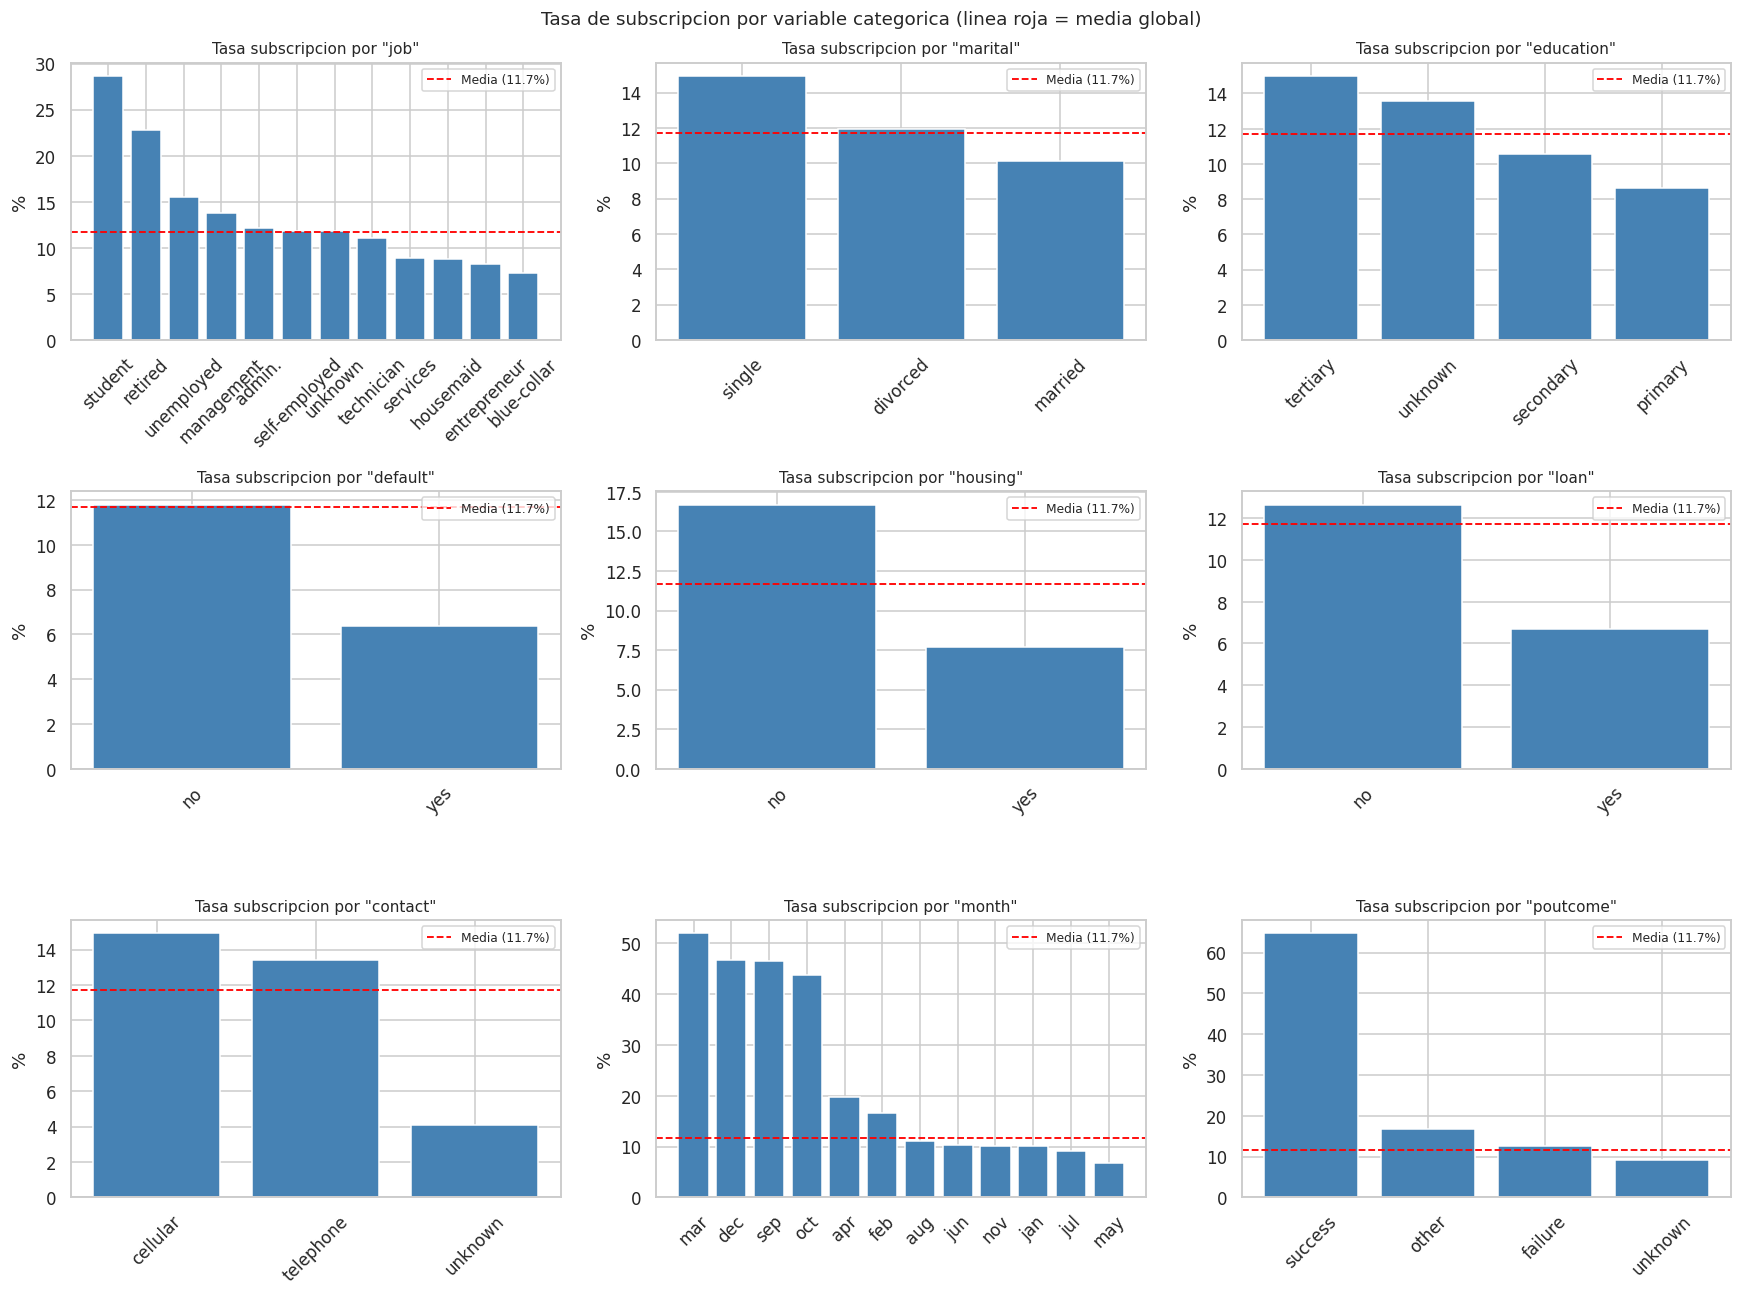

In [40]:
# ── Tasa de suscripción por variable categórica ───────────────────────────
# Para cada categoría calculamos: qué % de clientes de ese grupo suscribió.

cat_cols    = df.select_dtypes(include='object').columns.drop('y').tolist()
n_cat       = len(cat_cols)
n_cols_plot = 3
n_rows_plot = int(np.ceil(n_cat / n_cols_plot))  # calculado dinámicamente

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()

media_global = df['y'].eq('yes').mean() * 100

for i, col in enumerate(cat_cols):
    tasa = (
        df.groupby(col)['y']
          .apply(lambda x: (x == 'yes').mean() * 100)
          .sort_values(ascending=False)
    )
    axes[i].bar(tasa.index, tasa.values, color='steelblue', edgecolor='white')
    axes[i].axhline(media_global, color='red', linestyle='--',
                    linewidth=1.2, label=f'Media ({media_global:.1f}%)')
    axes[i].set_title(f'Tasa subscripcion por "{col}"', fontsize=10)
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

for j in range(n_cat, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Tasa de subscripcion por variable categorica (linea roja = media global)',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento

In [41]:
# ── Codificación de variables categóricas ─────────────────────────────────
# Random Forest necesita inputs numéricos.
# Usamos Label Encoding: asigna un entero a cada categoría.

df_enc = df.copy()
le = LabelEncoder()

for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])

print('Columnas codificadas OK')
df_enc.head(3)

Columnas codificadas OK


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0


In [42]:
# ── Separamos features y target ────────────────────────────────────────────
# LabelEncoder asigna 0 a 'no' y 1 a 'yes' (orden alfabético)

X = df_enc.drop(columns='y')
y = df_enc['y']

print('Features:', X.shape[1], 'columnas,', X.shape[0], 'filas')
print('Target  :', y.value_counts().to_dict(), ' (0=no, 1=yes)')

Features: 16 columnas, 45211 filas
Target  : {0: 39922, 1: 5289}  (0=no, 1=yes)


In [43]:
# ── División Train / Test (80% / 20%) ─────────────────────────────────────
# stratify=y: la proporción de clases es la misma en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print('Train :', X_train.shape[0], 'muestras')
print('Test  :', X_test.shape[0],  'muestras')
print('% yes en train:', round(y_train.mean() * 100, 2), '%')
print('% yes en test :', round(y_test.mean() * 100, 2),  '%')
print('Proporcion de clases identica en ambos conjuntos (stratify OK)')

Train : 36168 muestras
Test  : 9043 muestras
% yes en train: 11.7 %
% yes en test : 11.7 %
Proporcion de clases identica en ambos conjuntos (stratify OK)


---
## 3. Random Forest — Modelo Baseline

Antes de buscar hiperparámetros necesitamos un **punto de partida (baseline)**.  


### ¿Qué es un Random Forest?

Un **ensemble de árboles de decisión** con dos fuentes de aleatoriedad:

**Bagging:** cada árbol se entrena sobre una muestra aleatoria *con reemplazo* del dataset.

La predicción final es la **votación por mayoría** → mucho más robusto que un árbol individual.

In [44]:
# ── Entrenamiento del baseline ─────────────────────────────────────────────
print('Entrenando Random Forest baseline...')
t0 = time.time()

rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # class_weight='balanced': penaliza más los errores en la clase minoritaria
    random_state=SEED,
    n_jobs=-1           # n_jobs=-1: usa todos los núcleos del procesador
)
rf_base.fit(X_train, y_train)

print('Completado en', round(time.time() - t0, 1), 's')

#max_depth = None
#min_samples_leaf = 1
#n_estimators=100

Entrenando Random Forest baseline...
Completado en 4.1 s


In [45]:
# ── Función auxiliar: evaluar cualquier modelo ─────────────────────────────
# La reutilizamos en todas las secciones.

def evaluar_modelo(modelo, X_te, y_te, nombre='Modelo'):
    """Imprime métricas clave y devuelve un dict con los resultados."""
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    print(SEP)
    print(' ', nombre)
    print(SEP)
    print('  Accuracy :', round(acc, 4), '  ->', str(round(acc * 100, 1)) + '%')
    print('  F1-Score :', round(f1, 4))
    print('  AUC-ROC  :', round(auc, 4))
    print(SEP)
    print(classification_report(
        y_te, y_pred,
        target_names=['No suscribe (0)', 'Suscribe (1)']
    ))
    return {
        'nombre': nombre, 'accuracy': acc, 'f1': f1, 'auc': auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }


res_base = evaluar_modelo(rf_base, X_test, y_test, 'RF Baseline')

----------------------------------------------------
  RF Baseline
----------------------------------------------------
  Accuracy : 0.9026   -> 90.3%
  F1-Score : 0.4525
  AUC-ROC  : 0.9262
----------------------------------------------------
                 precision    recall  f1-score   support

No suscribe (0)       0.92      0.98      0.95      7985
   Suscribe (1)       0.66      0.34      0.45      1058

       accuracy                           0.90      9043
      macro avg       0.79      0.66      0.70      9043
   weighted avg       0.89      0.90      0.89      9043



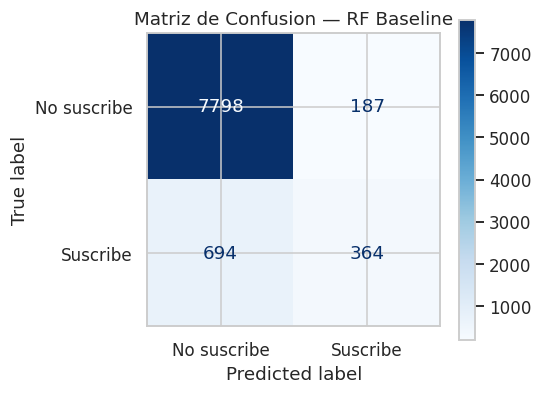

In [46]:
# ── Matriz de confusión ────────────────────────────────────────────────────
#   VP (True Positive) : predijo 'yes'  y era 'yes'  -> conversion detectada
#   VN (True Negative) : predijo 'no'   y era 'no'   -> rechazo detectado
#   FP (False Positive): predijo 'yes'  y era 'no'   -> llamada innecesaria
#   FN (False Negative): predijo 'no'   y era 'yes'  -> cliente perdido

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, res_base['y_pred'],
    display_labels=['No suscribe', 'Suscribe'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusion — RF Baseline', fontsize=12)
plt.tight_layout()
plt.show()

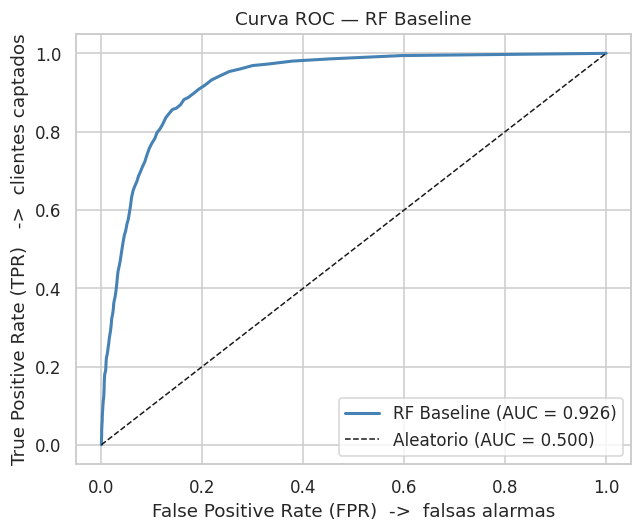

In [47]:
# ── Curva ROC del baseline ─────────────────────────────────────────────────
# AUC = 0.5 -> modelo aleatorio  |  AUC = 1.0 -> modelo perfecto

fpr_b, tpr_b, _ = roc_curve(y_test, res_base['y_prob'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_b, tpr_b, lw=2, color='steelblue',
        label='RF Baseline (AUC = ' + str(round(res_base['auc'], 3)) + ')')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (FPR)  ->  falsas alarmas')
ax.set_ylabel('True Positive Rate (TPR)   ->  clientes captados')
ax.set_title('Curva ROC — RF Baseline')
ax.legend()
plt.tight_layout()
plt.show()

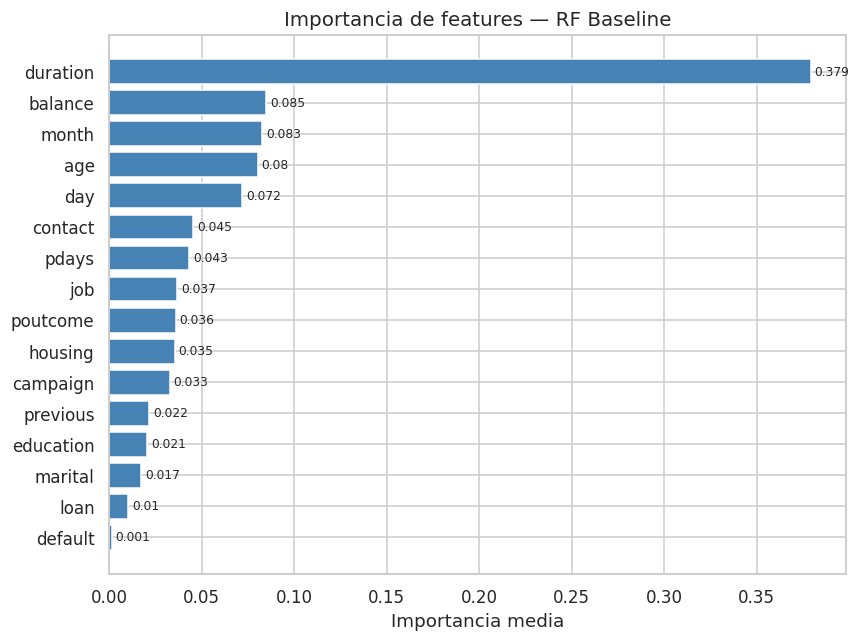

Top 5 features mas importantes:
duration    0.379152
balance     0.084972
month       0.082665
age         0.080456
day         0.071877


In [48]:
# ── Importancia de features (baseline) ────────────────────────────────────
importances_base = pd.Series(
    rf_base.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(
    importances_base.index, importances_base.values,
    color='steelblue', edgecolor='white'
)
for bar, val in zip(bars, importances_base.values):
    ax.text(
        val + 0.002, bar.get_y() + bar.get_height() / 2,
        str(round(val, 3)), va='center', fontsize=8
    )
ax.set_title('Importancia de features — RF Baseline', fontsize=13)
ax.set_xlabel('Importancia media')
plt.tight_layout()
plt.show()

print('Top 5 features mas importantes:')
print(importances_base.tail(5)[::-1].to_string())

---
## 4. Búsqueda de hiperparámetros — GridSearchCV

### ¿Qué es un hiperparámetro?

Los **hiperparámetros** son los parámetros de configuración que fijamos *antes* del entrenamiento. En Random Forest:

| Hiperparámetro | Qué controla | Efecto |
|----------------|-------------|--------|
| `n_estimators` | Nº de árboles | ↑ → más estable, más lento |
| `max_depth` | Profundidad máxima | ↑ → más complejo, riesgo overfitting |
| `min_samples_split` | Mínimo muestras para dividir nodo | ↑ → más simple |
| `min_samples_leaf` | Mínimo muestras en hoja | ↑ → más simple |
| `max_features` | Features candidatos por split | ↑ → árboles más correlados |

### GridSearchCV

Prueba **todas las combinaciones posibles** de la rejilla con validación cruzada.

In [49]:
# ── Definimos la rejilla de hiperparámetros ────────────────────────────────
# 3 x 2 x 2 = 12 combinaciones x 5 folds = 60 fits

param_grid = {
    'n_estimators'    : [100, 200, 300],  #numero de arboles
    'max_depth'       : [10, 20],         #profundidad
    'min_samples_leaf': [1, 5],           #El número mínimo de muestras que debe tener una hoja final del árbol.
}

n_comb = 1
for v in param_grid.values():
    n_comb *= len(v)

print('Combinaciones en la rejilla :', n_comb)
print('Total de fits (comb x cv=5) :', n_comb * 5)

Combinaciones en la rejilla : 12
Total de fits (comb x cv=5) : 60


In [50]:
# ── GridSearchCV ───────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='roc_auc', # scoring='roc_auc': optimizamos AUC (mejor que accuracy con clases desbalanceadas)
    cv=5,              # 5 folds
    n_jobs=-1,
    verbose=1,
    refit=True  # refit=True       : reentrena el mejor modelo sobre todo X_train al terminar
)

print('Ejecutando GridSearchCV...')
t0 = time.time()
grid_search.fit(X_train, y_train)
t_grid = time.time() - t0

print('Completado en', round(t_grid, 1), 's')
print('Mejor combinacion encontrada:')
for k, v in grid_search.best_params_.items():
    print(' ', k, '=', v)
print('Mejor AUC en CV :', round(grid_search.best_score_, 4))

Ejecutando GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Completado en 365.6 s
Mejor combinacion encontrada:
  max_depth = 20
  min_samples_leaf = 5
  n_estimators = 200
Mejor AUC en CV : 0.9274


In [51]:
# ── Evaluación del mejor modelo de GridSearch ─────────────────────────────

rf_grid_best = grid_search.best_estimator_
res_grid = evaluar_modelo(rf_grid_best, X_test, y_test, 'RF GridSearchCV')

#No hemos mejorado

----------------------------------------------------
  RF GridSearchCV
----------------------------------------------------
  Accuracy : 0.8883   -> 88.8%
  F1-Score : 0.6121
  AUC-ROC  : 0.9263
----------------------------------------------------
                 precision    recall  f1-score   support

No suscribe (0)       0.97      0.91      0.93      7985
   Suscribe (1)       0.52      0.75      0.61      1058

       accuracy                           0.89      9043
      macro avg       0.74      0.83      0.77      9043
   weighted avg       0.91      0.89      0.90      9043



---
## 5. Búsqueda de hiperparámetros — RandomizedSearchCV

### ¿Por qué RandomizedSearch?

GridSearch explora **todas** las combinaciones — inviable en espacios grandes.
**RandomizedSearchCV** muestrea aleatoriamente `n_iter` combinaciones:

- Puede explorar **rangos continuos** (distribuciones estadísticas)
- Tiempo de cómputo **controlado**
- Empiricamente tan bueno como GridSearch con mucho menos tiempo

> 📖 Bergstra & Bengio (2012): RandomSearch supera a GridSearch
> cuando pocos hiperparámetros son los verdaderamente importantes.

In [52]:
# ── Espacio de búsqueda con distribuciones continuas ──────────────────────
# randint(a, b) muestrea enteros uniformes en [a, b]

param_dist = {
    'n_estimators'     : randint(50, 500),
    'max_depth'        : randint(5, 30),
    'min_samples_split': randint(2, 20),      #Es el número mínimo de muestras necesario para dividir un nodo.
    'min_samples_leaf' : randint(1, 15),      #Es el número mínimo de muestras que debe quedar en una hoja final.
    'max_features'     : ['sqrt', 'log2'],    #Controla cuántas variables mira cada árbol en cada división.
}

N_ITER = 30  # 30 combinaciones x 5 folds = 150 fits

print('Espacio teorico  : practicamente infinito (distribuciones continuas)')
print('Combinaciones    :', N_ITER, 'x 5 folds =', N_ITER * 5, 'fits')
print('(GridSearch con 5 params a 5 valores cada uno =', 5**5 * 5, 'fits)')

#Si el dataset tiene 100 variables
#sqrt(100) = 10 variables
#log2(100) ≈ 6 o 7 variables
#Esto introduce aleatoriedad y ayuda a que los árboles no sean todos iguales.

Espacio teorico  : practicamente infinito (distribuciones continuas)
Combinaciones    : 30 x 5 folds = 150 fits
(GridSearch con 5 params a 5 valores cada uno = 15625 fits)


In [53]:
# ── RandomizedSearchCV ─────────────────────────────────────────────────────

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True
)

print('Ejecutando RandomizedSearchCV...')
t0 = time.time()
random_search.fit(X_train, y_train)
t_rand = time.time() - t0

print('Completado en', round(t_rand, 1), 's')
print('Mejor combinacion encontrada:')
for k, v in random_search.best_params_.items():
    print(' ', k, '=', v)
print('Mejor AUC en CV :', round(random_search.best_score_, 4))

Ejecutando RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Completado en 1217.0 s
Mejor combinacion encontrada:
  max_depth = 26
  max_features = sqrt
  min_samples_leaf = 3
  min_samples_split = 2
  n_estimators = 276
Mejor AUC en CV : 0.9286


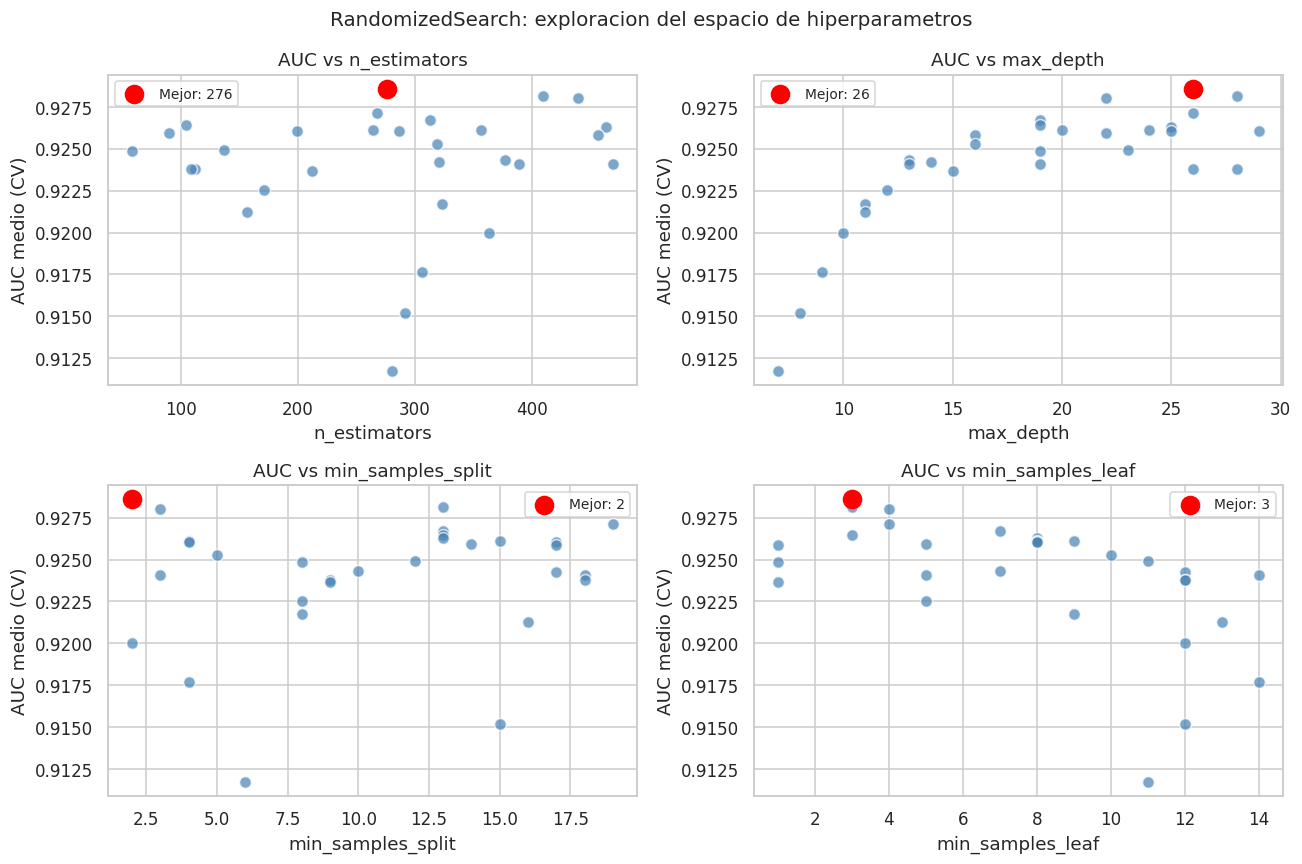

In [54]:
# ── Visualización: exploración del espacio ────────────────────────────────
# Cada punto = una combinación aleatoria probada.
# Eje Y = AUC en validación cruzada.
# Si el AUC es plano a lo largo del eje X -> ese hiperparámetro importa poco.

df_rand = pd.DataFrame(random_search.cv_results_).sort_values(
    'mean_test_score', ascending=False
)

hipers = ['param_n_estimators', 'param_max_depth',
          'param_min_samples_split', 'param_min_samples_leaf']
labels = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (h, lbl) in enumerate(zip(hipers, labels)):
    axes[i].scatter(
        df_rand[h].astype(float), df_rand['mean_test_score'],
        alpha=0.7, color='steelblue', edgecolors='white', s=60
    )
    # Marcamos el mejor punto en rojo
    best_x = random_search.best_params_.get(lbl)
    if best_x is not None:
        axes[i].scatter(
            best_x, random_search.best_score_,
            color='red', s=140, zorder=5,
            label='Mejor: ' + str(best_x)
        )
        axes[i].legend(fontsize=9)
    axes[i].set_xlabel(lbl)
    axes[i].set_ylabel('AUC medio (CV)')
    axes[i].set_title('AUC vs ' + lbl)

fig.suptitle('RandomizedSearch: exploracion del espacio de hiperparametros', fontsize=13)
plt.tight_layout()
plt.show()

In [55]:
# ── Evaluación del mejor modelo de RandomSearch ───────────────────────────

rf_rand_best = random_search.best_estimator_
res_rand = evaluar_modelo(rf_rand_best, X_test, y_test, 'RF RandomizedSearchCV')

----------------------------------------------------
  RF RandomizedSearchCV
----------------------------------------------------
  Accuracy : 0.903   -> 90.3%
  F1-Score : 0.6172
  AUC-ROC  : 0.9267
----------------------------------------------------
                 precision    recall  f1-score   support

No suscribe (0)       0.96      0.93      0.94      7985
   Suscribe (1)       0.57      0.67      0.62      1058

       accuracy                           0.90      9043
      macro avg       0.76      0.80      0.78      9043
   weighted avg       0.91      0.90      0.91      9043



---
## 6. Validación robusta — K-Fold Cross-Validation

### ¿Por qué Cross-Validation?

Al evaluar sobre un único test set, el resultado puede depender de cómo se hizo el split.
**K-Fold CV** entrena el modelo K veces; cada vez usa K-1 folds para entrenar y 1 para validar.
La métrica final es la **media** de las K evaluaciones → estimación más robusta.

```
Fold 1:  [VAL] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN]
Fold 2:  [TRN] [VAL] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN]
   ...                              ...
Fold 10: [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [TRN] [VAL]
```

Usamos **StratifiedKFold** para mantener la proporción de clases en cada fold.

In [56]:
# ── Seleccionamos el mejor modelo de las dos búsquedas ────────────────────

print('GridSearch   -> AUC en CV:', round(grid_search.best_score_, 4))
print('RandomSearch -> AUC en CV:', round(random_search.best_score_, 4))

if grid_search.best_score_ >= random_search.best_score_:
    mejor_modelo   = rf_grid_best
    nombre_ganador = 'GridSearchCV'
else:
    mejor_modelo   = rf_rand_best
    nombre_ganador = 'RandomizedSearchCV'

print('\nMejor modelo:', nombre_ganador)

GridSearch   -> AUC en CV: 0.9274
RandomSearch -> AUC en CV: 0.9286

Mejor modelo: RandomizedSearchCV


In [57]:
# ── 10-Fold Cross-Validation ──────────────────────────────────────────────
# Usamos todo X (train + test) para una estimación más robusta.

K   = 10
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

print('Ejecutando', K, '-Fold CV...')
t0 = time.time()

scores_auc = cross_val_score(mejor_modelo, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
scores_f1  = cross_val_score(mejor_modelo, X, y, cv=skf, scoring='f1',      n_jobs=-1)

print('Completado en', round(time.time() - t0, 1), 's\n')
print('AUC por fold :', np.round(scores_auc, 4))
print('Media AUC    :', round(scores_auc.mean(), 4), ' +/-', round(scores_auc.std(), 4))
print()
print('F1  por fold :', np.round(scores_f1, 4))
print('Media F1     :', round(scores_f1.mean(), 4),  ' +/-', round(scores_f1.std(), 4))

Ejecutando 10 -Fold CV...
Completado en 259.8 s

AUC por fold : [0.932  0.9338 0.9267 0.9345 0.9315 0.923  0.9299 0.9364 0.9239 0.927 ]
Media AUC    : 0.9299  +/- 0.0043

F1  por fold : [0.6129 0.6383 0.6071 0.6201 0.6062 0.5874 0.6473 0.6263 0.5947 0.6042]
Media F1     : 0.6144  +/- 0.0178


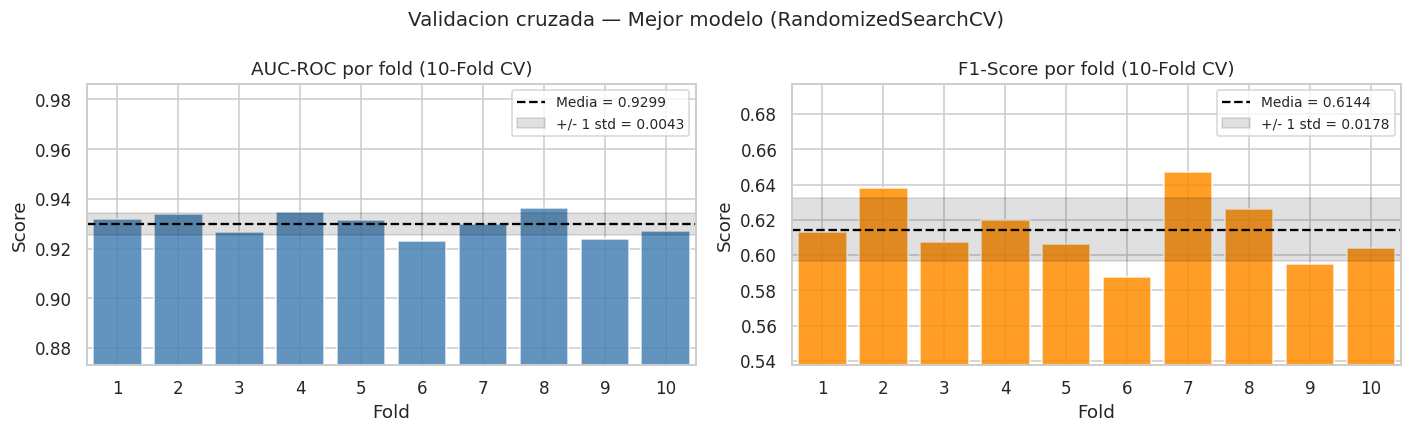

In [58]:
# ── Visualización de los scores por fold ──────────────────────────────────
# Barras similares = modelo estable
# Mucha variación  = modelo sensible a la partición

folds = np.arange(1, K + 1)
x_lim = [0.5, K + 0.5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, scores, titulo, color in [
    (axes[0], scores_auc, 'AUC-ROC por fold (' + str(K) + '-Fold CV)', 'steelblue'),
    (axes[1], scores_f1,  'F1-Score por fold (' + str(K) + '-Fold CV)', 'darkorange')
]:
    ax.bar(folds, scores, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(
        scores.mean(), color='black', linestyle='--', lw=1.5,
        label='Media = ' + str(round(scores.mean(), 4))
    )
    ax.fill_between(
        x_lim,
        scores.mean() - scores.std(),
        scores.mean() + scores.std(),
        alpha=0.12, color='black',
        label='+/- 1 std = ' + str(round(scores.std(), 4))
    )
    ax.set_xticks(folds)
    ax.set_xlim(x_lim)
    ax.set_ylim(
        max(0.0, float(scores.min()) - 0.05),
        min(1.0, float(scores.max()) + 0.05)
    )
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_title(titulo)
    ax.legend(fontsize=9)

fig.suptitle('Validacion cruzada — Mejor modelo (' + nombre_ganador + ')', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Comparativa final

In [59]:
# ── Tabla comparativa de todos los modelos ────────────────────────────────

tabla = pd.DataFrame([
    {
        'Modelo'         : 'RF Baseline',
        'Accuracy'       : round(res_base['accuracy'], 4),
        'F1-Score'       : round(res_base['f1'], 4),
        'AUC-ROC (test)' : round(res_base['auc'], 4),
        'AUC CV (media)' : '-',
        'AUC CV (std)'   : '-',
    },
    {
        'Modelo'         : 'RF GridSearchCV',
        'Accuracy'       : round(res_grid['accuracy'], 4),
        'F1-Score'       : round(res_grid['f1'], 4),
        'AUC-ROC (test)' : round(res_grid['auc'], 4),
        'AUC CV (media)' : round(grid_search.best_score_, 4),
        'AUC CV (std)'   : '-',
    },
    {
        'Modelo'         : 'RF RandomizedSearchCV',
        'Accuracy'       : round(res_rand['accuracy'], 4),
        'F1-Score'       : round(res_rand['f1'], 4),
        'AUC-ROC (test)' : round(res_rand['auc'], 4),
        'AUC CV (media)' : round(random_search.best_score_, 4),
        'AUC CV (std)'   : '-',
    },
    {
        'Modelo'         : 'Mejor + ' + str(K) + '-Fold CV (' + nombre_ganador + ')',
        'Accuracy'       : '-',
        'F1-Score'       : '-',
        'AUC-ROC (test)' : '-',
        'AUC CV (media)' : round(scores_auc.mean(), 4),
        'AUC CV (std)'   : round(scores_auc.std(), 4),
    },
]).set_index('Modelo')

print('Tabla comparativa de modelos:')
print(tabla.to_string())

Tabla comparativa de modelos:
                                        Accuracy F1-Score AUC-ROC (test) AUC CV (media) AUC CV (std)
Modelo                                                                                              
RF Baseline                               0.9026   0.4525         0.9262              -            -
RF GridSearchCV                           0.8883   0.6121         0.9263         0.9274            -
RF RandomizedSearchCV                      0.903   0.6172         0.9267         0.9286            -
Mejor + 10-Fold CV (RandomizedSearchCV)        -        -              -         0.9299       0.0043


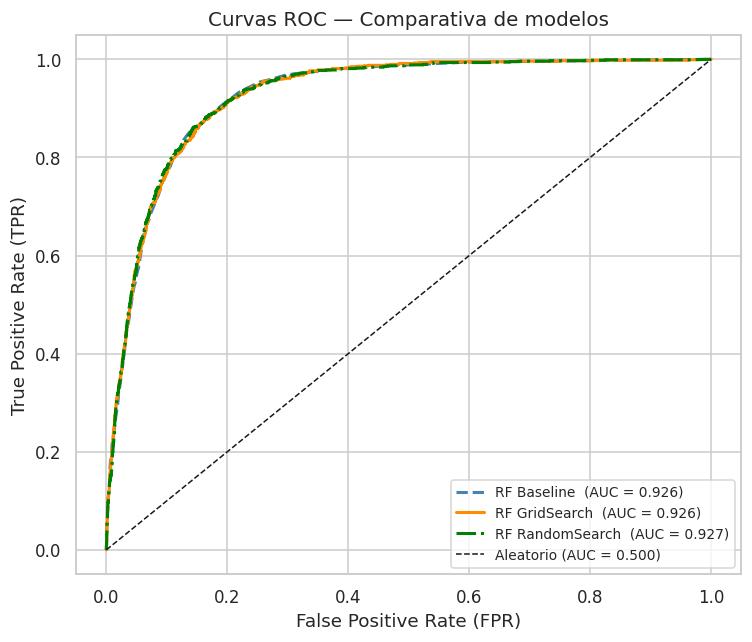

In [60]:
# ── Curvas ROC comparativas ────────────────────────────────────────────────

modelos_comparar = [
    (res_base, 'RF Baseline',     'steelblue', '--'),
    (res_grid, 'RF GridSearch',   'darkorange', '-'),
    (res_rand, 'RF RandomSearch', 'green',     '-.'),
]

fig, ax = plt.subplots(figsize=(7, 6))
for res, label, color, ls in modelos_comparar:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color, linestyle=ls,
            label=label + '  (AUC = ' + str(round(res['auc'], 3)) + ')')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('Curvas ROC — Comparativa de modelos', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

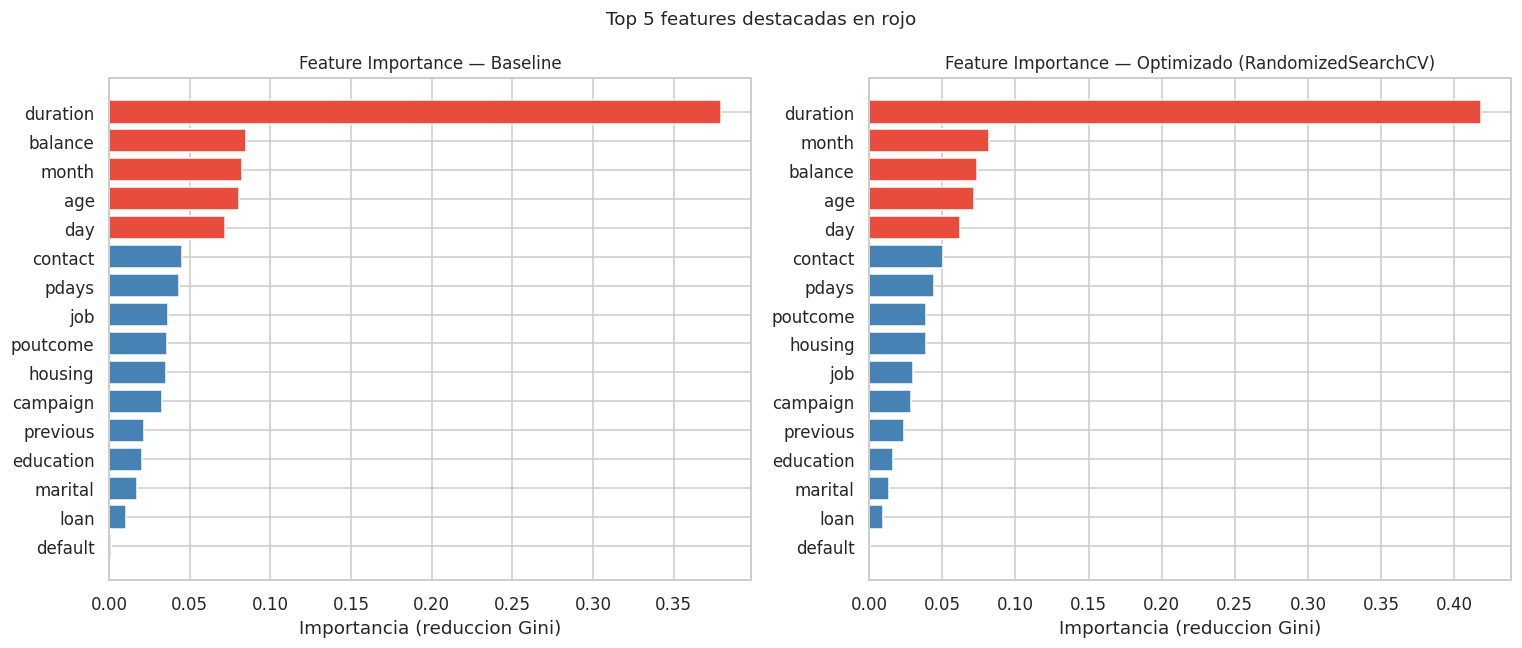

In [61]:
# ── Feature importance: Baseline vs Modelo optimizado ────────────────────

importances_opt = pd.Series(
    mejor_modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imps, titulo in [
    (axes[0], importances_base, 'Baseline'),
    (axes[1], importances_opt,  'Optimizado (' + nombre_ganador + ')')
]:
    n = len(imps)
    colors = ['#e74c3c' if i >= n - 5 else 'steelblue' for i in range(n)]
    ax.barh(imps.index, imps.values, color=colors, edgecolor='white')
    ax.set_title('Feature Importance — ' + titulo, fontsize=11)
    ax.set_xlabel('Importancia (reduccion Gini)')

fig.suptitle('Top 5 features destacadas en rojo', fontsize=12)
plt.tight_layout()
plt.show()

---
## Conclusiones

### Resultados obtenidos

| Aspecto | Resultado |
|---------|----------|
| **Baseline** | AUC ~0.92 con parámetros por defecto — Random Forest ya es muy competente de base |
| **GridSearchCV** | Búsqueda sistemática en rejilla pequeña, ideal para explorar interacciones |
| **RandomizedSearchCV** | Mismo tiempo, espacio mucho mayor, resultados comparables |
| **K-Fold CV** | Confirma la estabilidad del modelo (std bajo entre folds) |

### Lecciones clave

1. **Random Forest es robusto desde el principio:** incluso con parámetros por defecto el AUC supera 0.90.

2. **Desbalance de clases** → usar `class_weight='balanced'` y AUC-ROC en lugar de accuracy (un modelo que siempre predice 'no' tendría 88% de accuracy pero cero utilidad).

3. **GridSearch vs RandomSearch:** GridSearch es exhaustivo pero costoso. RandomSearch explora más amplio con el mismo tiempo. Para espacios grandes, RandomSearch suele ganar.

4. **K-Fold no mejora el modelo** — mide su **varianza**. Un std bajo en AUC indica que el modelo generaliza de forma consistente.

5. **`duration` es leaky:** sólo se conoce después de la llamada. En producción la excluiríamos.

### Próximos pasos

- Gradient Boosting: XGBoost, LightGBM
- SMOTE para oversampling de la clase minoritaria  
- Optuna para búsqueda bayesiana de hiperparámetros
- SHAP values para explicabilidad a nivel de instancia